# **Asignatura**: Aprendizaje Automático

**Práctica 3**: Introducción a Deep Learning

**Valoración máxima**: 10 puntos

**Fecha límite de entrega**: 23 de Mayo de 2026 a las 23:59

**Procedimiento de entrega**: a través de PRADO

### Nombre completo: Ismael Sallami Moreno



**Normas de desarrollo y entrega de trabajos**

- Única y exclusivamente se debe entregar este Notebook de Colab (fichero `.ipynb`). **No es necesario entregar ninguna memoria externa** (por ejemplo, en `.pdf`).

- El código debe estar bien comentado (explicando lo que realizan los distintos apartados y/o bloques), y todas las decisiones tomadas y el trabajo desarrollado (incluyendo los conceptos fundamentales subyacentes) deben documentarse ampliamente en celdas de texto. Es obligatorio documentar las valoraciones y decisiones adoptadas en el desarrollo de cada uno de los apartados. Debe incluirse también tanto una descripción de las principales funciones (Python/scikit-learn) empleadas (para mostrar que el alumno comprende, a nivel técnico, lo que está haciendo), como una valoración razonada sobre la calidad de los resultados obtenidos. **Sin esta documentación, se considera que el trabajo NO ha sido presentado**.

- La entrega en PRADO está configurada para permitir sucesivas entregas de la práctica. Desde este punto de vista, se recomienda subir versiones de la práctica a medida que se van realizando los distintos ejercicios propuestos, y no dejarlo todo para el final.

- Se debe respetar la estructura y secciones del Notebook. Esto servirá para agilizar las correcciones, así como para identificar con facilidad qué ejercicio/apartado se está respondiendo.

- El código **NO debe escribir nada a disco**.

- El **path de lectura desde Google Drive debe ser siempre el mismo**, que es el que se indica en este Notebook.

- Una entrega es apta para ser corregida si se puede ejecutar de principio a fin sin errores. Es decir, un ejercicio con errores de ejecución tendrá una calificación de 0.

- No es válido usar opciones en las entradas (es decir, utilizar el comando `input()`, por ejemplo, para que el usuario escoja el valor de las variables para ejecutar el programa). Para ello, se deben fijar al comienzo los valores

por defecto que se consideren óptimos o que se soliciten en el enunciado.

- Se entrega solamente este Notebook, y no los datos empleados.


# **Ejercicio 1: Aprendizaje Supervisado (5 puntos)**

## 1.1 Contexto: Análisis de Sentimientos en Reseñas de Cine

En este ejercicio abordaremos un problema clásico de **Procesamiento de Lenguaje Natural (NLP)** utilizando redes neuronales densas (Perceptrón Multicapa).

El objetivo es clasificar reseñas de películas como **Positivas (1)** o **Negativas (0)** basándose en el texto de la crítica.

**Dataset:** IMDB Movie Reviews. Contiene 50.000 reseñas altamente polares. Keras proporciona este dataset preprocesado, donde las palabras ya han sido convertidas a secuencias de enteros (índices en un diccionario).

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt


# Importamos la clase Sequential y la capa Dense desde tensorflow.keras
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, models

In [2]:
# Carga del dataset IMDB limitado a las 10,000 palabras más frecuentes
(train_data, train_labels), (test_data, test_labels) = keras.datasets.imdb.load_data(num_words=10000)

print(f"Entrenamiento: {len(train_data)} reseñas")
print(f"Test: {len(test_data)} reseñas")

# Ejemplo de una reseña (enteros)
print("Ejemplo de reseña (indices):", train_data[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Entrenamiento: 25000 reseñas
Test: 25000 reseñas
Ejemplo de reseña (indices): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88

## 1.2 Tareas a realizar

El alumno debe completar los siguientes apartados:

1.  **Preprocesado de datos (Vectorización):**
    * Las listas de enteros tienen longitudes variables, lo cual no es admisible para una red densa estándar. Debe transformar las listas en tensores de tamaño fijo.
    * **Tarea:** Implemente una función para realizar **One-hot Encoding** (o Multi-hot) que convierta cada reseña en un vector de dimensión 10,000 (donde 1 indica la presencia de la palabra y 0 su ausencia).
    * Vectorice tanto los datos de train como los de test.

2.  **Construcción del Modelo:**
    * Diseñe una red neuronal secuencial (`tf.keras.Sequential`).
    * Use 2 o 3 capas densas (`Dense`).
    * Use funciones de activación `relu` para las capas ocultas.
    * **Importante:** La capa de salida debe tener 1 sola neurona con activación `sigmoid` (para clasificación binaria).

3.  **Compilación y Entrenamiento:**
    * Optimizador: `rmsprop` o `adam`.
    * Función de pérdida: `binary_crossentropy`.
    * Métrica: `accuracy`.
    * Separe una parte de los datos de entrenamiento para validación.
    * Entrene durante 20 épocas.

4.  **Evaluación:**
    * Muestre la gráfica la evolución de la pérdida (`loss`) y la precisión (`accuracy`) tanto en entrenamiento como en validación.
    * Evalúe el modelo final sobre el conjunto de test.

<mark> Solución <mark>

### 1. Preprocesado de datos (Vectorización)

En el diseño de modelos de Deep Learning mediante el uso de la API Keras de TensorFlow, el tipo central de datos es el array multidimensional o tensor. Un tensor es una estructura de datos inmutable (o modificable a través de variables específicas tf.Variable) que requiere una dimensionalidad fija y definida.

Dado que nuestras reseñas (train_data y test_data) son listas de longitud variable (cada película tiene críticas más largas o más cortas), no podemos inyectarlas directamente en una capa Dense estándar. Debemos transformarlas en tensores de tamaño fijo.

Para ello, utilizaremos una técnica de codificación denominada Multi-hot Encoding (una variante del One-hot Encoding aplicada a conjuntos). Esta técnica transforma cada lista de enteros en un vector de 0s y 1s de dimensión fija (en nuestro caso, 10.000, que es el tamaño del vocabulario). Si el índice de una palabra aparece en la reseña, la posición correspondiente en el vector se marca con un 1; de lo contrario, permanece en 0.

In [3]:
def vectorizar_secuencias(secuencias, dimension=10000):
    """
    Convierte una lista de secuencias en un array bidimensional utilizando una representación binaria de Saco de Palabras (Bag-of-Words), también referida técnicamente como Multi-hot Encoding.

    Parámetros:
    -----------
    secuencias : list de list de int
        Lista principal que contiene las reseñas. Cada reseña es una sublista de enteros.
    dimension : int, opcional
        El tamaño máximo del vocabulario, que define la longitud del vector de salida
        para cada secuencia (por defecto 10000).

    Retorna:
    --------
    resultados : numpy.ndarray
        Una matriz de NumPy de dimensiones (len(secuencias), dimension) conteniendo
        valores de punto flotante 0.0 y 1.0.
    """
    # Inicializamos una matriz de ceros con la forma (número_de_reseñas, dimensión_vocabulario)
    # Se utiliza el tipo float32, altamente compatible con los tensores de TensorFlow.
    resultados = np.zeros((len(secuencias), dimension), dtype=np.float32)

    # Iteramos sobre cada reseña en la lista de secuencias
    for i, secuencia in enumerate(secuencias):
        # Aprovechamos la indexación avanzada de NumPy para asignar 1.0
        # en los índices que corresponden a las palabras de esta reseña específica.
        resultados[i, secuencia] = 1.0

    return resultados

# Aplicamos la función de vectorización a nuestros datos de entrenamiento y de test.
# Estos ndarray serán fácilmente convertibles a tensores de TensorFlow posteriormente.
x_train = vectorizar_secuencias(train_data)
x_test = vectorizar_secuencias(test_data)

# Mostramos el resultado para verificar la transformación geométrica
print(f"Forma del tensor x_train: {x_train.shape}")
print(f"Forma del tensor x_test: {x_test.shape}")
print(f"Ejemplo de la primera reseña vectorizada (primeros 50 elementos):\\n{x_train[0, :50]}")

Forma del tensor x_train: (25000, 10000)
Forma del tensor x_test: (25000, 10000)
Ejemplo de la primera reseña vectorizada (primeros 50 elementos):\n[0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0.
 0. 1. 1. 0. 1. 0. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 1. 0.
 1. 0.]


#### Análisis de la Vectorización y Verificación de Resultados

- Verificación de las Dimensiones del Tensor: La salida generada por nuestro proceso de vectorización nos indica que tanto x_train como x_test tienen la forma (25000, 10000). Esta salida es estrictamente correcta y coherente con el planteamiento del problema:
  - 25.000 (Instancias): Corresponde al número total de ejemplos de entrenamiento $m$ en nuestro conjunto de datos. En el aprendizaje supervisado, nuestro conjunto de entrenamiento se define como un conjunto de pares $(x_i, y_i)$ para $i = 1, \dots, m$.  
  - 10.000 (Características): Corresponde a la dimensionalidad de nuestro espacio de entrada $\mathbb{R}^n$, donde $n = 10000$. Representa el vocabulario máximo que hemos permitido al cargar el dataset de IMDB. Cada reseña se ha proyectado en este espacio vectorial de tamaño fijo, un requisito fundamental para que los datos puedan ser procesados por las capas densas (Dense) de una red neuronal artificial.



#### Análisis Algorítmico y Complejidad

- Eficiencia Vectorial: En lugar de iterar manualmente por cada uno de los 10.000 elementos para comprobar si están en la secuencia original, inicializamos directamente un numpy.ndarray lleno de ceros (np.zeros). El uso de matrices multidimensionales NumPy (ndarray) es la base perfecta porque existe una conversión simple y directa hacia los tensores de TensorFlow (tf.convert_to_tensor).

- Indexación Avanzada de NumPy: La línea resultados[i, secuencia] = 1.0 es importante. Al pasarle una lista completa de enteros (secuencia) como índice a una fila (i), NumPy vectoriza la operación internamente a nivel de código C, haciendo que todas las posiciones indicadas pasen a valer 1.0 simultáneamente, evitando un bucle anidado ineficiente.

#### Análisis de Complejidad Matemática:

- Complejidad Temporal: $\mathcal{O}(N \times L)$, donde $N$ es el número total de reseñas (ej. 25.000) y $L$ es la longitud media de cada reseña. Esto es porque el bucle for se ejecuta $N$ veces, y la asignación interna procesa en promedio $L$ índices por iteración. Es un algoritmo sumamente eficiente.

- Complejidad Espacial: $\mathcal{O}(N \times D)$, donde $N$ es el número de secuencias y $D$ es la dimensión del vocabulario (10.000). Estamos creando en memoria matrices densas considerables ($25.000 \times 10.000 \approx 250$ millones de elementos de tipo coma flotante). Esto demandará una porción razonable de memoria RAM, pero es un paso preprocesal obligatorio para poder alimentar la primera capa densa (Dense) de nuestra arquitectura secuencial.


### 2. Construcción del Modelo

Fundamentos de la Arquitectura: Para resolver este problema de clasificación binaria de texto, diseñaremos un Perceptrón Multicapa (MLP) utilizando la API funcional y modular de Keras. La arquitectura se fundamenta en los siguientes componentes matemáticos y computacionales:

- Modelo Secuencial (tf.keras.Sequential): Esta clase permite la construcción rápida de modelos de redes neuronales hacia adelante (feedforward), donde la información fluye en una única dirección, desde la entrada hasta la salida, sin ciclos.
- Capas Densas (Dense): Utilizaremos capas densas o completamente conectadas, lo que significa que cada neurona de una capa recibe como entrada las salidas de todas las neuronas de la capa anterior.
- Activación en Capas Ocultas (ReLU): Las redes neuronales requieren transformaciones no lineales para aprender patrones complejos. Aplicaremos la función Rectified Linear Unit (ReLU), definida matemáticamente como $f(x) = \max\{0, x\}$. Esta función mitiga el problema de la desaparición del gradiente durante el entrenamiento y acelera la convergencia.
- Activación de Salida (Sigmoide): Al tratarse de un problema de clasificación binaria (reseña positiva vs. negativa), la capa final constará de una única neurona. Emplearemos la función de activación Sigmoide, definida como $f(x) = \frac{1}{1+e^{-x}}$. Esta función mapea cualquier valor real a un rango continuo entre 0 y 1, lo que permite interpretar la salida como la probabilidad de que la reseña pertenezca a la clase positiva.

In [4]:
def construir_modelo_analisis_sentimientos(input_dim=10000):
    """
    Construye y devuelve un modelo de red neuronal secuencial para
    clasificación binaria de textos.

    Parámetros:
    -----------
    input_dim : int
        Dimensionalidad del tensor de entrada (tamaño del vocabulario).

    Retorna:
    --------
    model : tf.keras.Sequential
        Modelo de Keras compilado computacionalmente pero sin entrenar.
    """

    # Instanciamos el modelo secuencial
    model = Sequential()

    # Capa Oculta 1: 16 neuronas, activación ReLU.
    # Es obligatorio definir 'Input' en la primera capa para que
    # el modelo sepa la dimensionalidad geométrica de los tensores de entrada.
    model.add(keras.Input(shape=(input_dim,)))
    model.add(Dense(16, activation='relu'))

    # Capa Oculta 2: 16 neuronas, activación ReLU.
    # La dimensionalidad de entrada se infiere automáticamente de la capa anterior.
    model.add(Dense(16, activation='relu'))

    # Capa de Salida: 1 única neurona, activación Sigmoide para obtener
    # una probabilidad en el intervalo [0, 1] (la probabilidad de la clase positiva).
    model.add(Dense(1, activation='sigmoid'))

    return model

# Generamos la instancia de nuestro modelo
modelo_imdb = construir_modelo_analisis_sentimientos()

# Imprimimos el resumen de la arquitectura para auditar los parámetros
modelo_imdb.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

#### Análisis de la Construcción del Modelo

La arquitectura diseñada corresponde a una Red Neuronal Artificial estándar (Perceptrón Multicapa), que son modelos matemáticos parametrizados inspirados en el funcionamiento del cerebro. Hemos optado por la clase Sequential de Keras, la cual permite la construcción de modelos construyendo una pila lineal de capas, sin ciclos ni conexiones cruzadas.  

1. Topología: El modelo consta de dos capas ocultas completamente conectadas (Dense) de 16 neuronas cada una. La elección de 16 neuronas es empíricamente sólida para conjuntos de datos de NLP de complejidad moderada, evitando un sobreajuste prematuro y manteniendo una capacidad de representación adecuada.
2. Activación ReLU: En las capas ocultas utilizamos la función Rectified Linear Unit, definida matemáticamente como $f(x)=\max\{0,x\}$. Su uso es fundamental en el Deep Learning moderno porque mitiga el problema de la desaparición del gradiente durante la propagación hacia atrás (backpropagation), introduciendo no linealidades sin saturar en el semieje positivo.  
3. Activación Sigmoide: La capa de salida tiene 1 neurona gobernada por la función sigmoide, $f(x)=\frac{1}{1+e^{-x}}$. Esta función proyecta el sumatorio ponderado de la última capa en el intervalo (0, 1), transformando la salida en una probabilidad bien definida que modela la pertenencia a la clase "Reseña Positiva" (la probabilidad complementaria, $1-f(x)$, corresponde a la clase negativa).  
4. Complejidad Paramétrica:
  - Capa 1: 10000 entradas $\times$ 16 neuronas + 16 sesgos (bias) = 160016 parámetros.
  - Capa 2: 16 entradas $\times$ 16 neuronas + 16 sesgos = 272 parámetros.
  - Capa Salida: 16 entradas $\times$ 1 neurona + 1 sesgo = 17 parámetros.
  - Total: 160305 parámetros entrenables.


#### Análisis Temporal y Espacial

Definamos $d = 10,000$ (dimensión de entrada), $h_1 = 16$, $h_2 = 16$ (neuronas ocultas), $c = 1$ (salida), $N$ como el número de instancias de entrenamiento y $E$ como el número de épocas. Denotamos el total de pesos como $W = (d \cdot h_1) + (h_1 \cdot h_2) + (h_2 \cdot c)$.

| Algoritmo / Fase | Temporal | Espacial |
| :--- | :--- | :--- |
| **Predicción** | $O(d \cdot h_1 + h_1 \cdot h_2 + h_2 \cdot c)$ | $O(W)$ (tamaño estático del modelo en memoria) |
| **Entrenamiento** | $O(E \cdot N \cdot W)$ | $O(W + B \cdot \max(d, h_1))$ (pesos + activaciones del Batch) |



#### 3. Compilación y Entrenamiento

Una vez definida la arquitectura, debemos configurar el proceso de aprendizaje. Este paso, conocido como compilación, permite al grafo de computación de TensorFlow prepararse para la optimización mediante tres componentes esenciales:

1. Función de Pérdida (loss): Es la métrica que el modelo intentará minimizar. Para problemas de clasificación binaria con salida sigmoide, la función estándar es la entropía cruzada binaria (binary_crossentropy). Matemáticamente, mide la discrepancia entre la distribución de probabilidad predicha y la real.
2. Optimizador: Es el algoritmo que actualiza los pesos de la red en función del gradiente de la función de pérdida. Utilizaremos RMSprop (Root Mean Square Propagation), un algoritmo de aprendizaje adaptativo que ajusta la tasa de aprendizaje para cada parámetro individualmente.
3. Métricas: A diferencia de la pérdida, las métricas se utilizan únicamente para monitorizar el rendimiento desde una perspectiva humana. El Accuracy (precisión) nos indicará el porcentaje de reseñas correctamente clasificadas.

Para garantizar que el modelo generalice correctamente, separaremos un conjunto de validación de 10,000 muestras. Esto nos permitirá evaluar el rendimiento del modelo en datos que no está utilizando directamente para ajustar sus pesos durante cada época de entrenamiento.

In [5]:
# Usamos la instancia del modelo creada y la matriz vectorizada de los apartados anteriores.

# Configuramos el grafo computacional para el entrenamiento.
# Seleccionamos 'rmsprop' como optimizador, altamente eficaz para manejar tensores dispersos
# y estabilizar el descenso de gradiente adaptando la tasa de aprendizaje por parámetro.
# La pérdida 'binary_crossentropy' es el estándar para salidas probabilísticas discretas en (0, 1).
modelo_imdb.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Definimos los hiperparámetros del bucle de entrenamiento.
# Un tamaño de lote (batch size) de 512 ofrece un buen equilibrio empírico entre
# la precisión de la estimación del gradiente y la eficiencia de la memoria/velocidad.
tamano_lote = 512
num_epocas = 20
fraccion_validacion = 0.2

# Iniciamos el proceso de optimización estocástica.
# Al establecer validation_split=0.2, Keras extrae el último 20% de las muestras de entrenamiento
# ANTES de barajarlas, reservándolas exclusivamente para la validación al final de cada época.
# Guardamos la salida en 'historial' para poder plotear las curvas de aprendizaje posteriormente.
historial = modelo_imdb.fit(
    x_train,
    train_labels,
    epochs=num_epocas,
    batch_size=tamano_lote,
    validation_split=fraccion_validacion,
    verbose=1
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.8119 - loss: 0.4729 - val_accuracy: 0.7704 - val_loss: 0.4678
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8999 - loss: 0.2881 - val_accuracy: 0.8688 - val_loss: 0.3267
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9234 - loss: 0.2204 - val_accuracy: 0.8876 - val_loss: 0.2801
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9367 - loss: 0.1820 - val_accuracy: 0.8874 - val_loss: 0.2789
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9441 - loss: 0.1573 - val_accuracy: 0.8914 - val_loss: 0.2796
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9517 - loss: 0.1383 - val_accuracy: 0.8912 - val_loss: 0.2889
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9595 - loss: 0.1210 - val_accuracy: 0.8898 - val_loss: 0.3040
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9643 - loss: 0.1066 - val_accuracy: 0.8846 - v

#### Análisis de la Salida

A la vista de los resultados del registro de entrenamiento, podemos extraer conclusiones fundamentales sobre el comportamiento geométrico y estadístico de nuestro Perceptrón Multicapa. El límite de este modelo (~85-88% de precisión) se debe en parte a que la representación de Bag-of-Words pierde la información secuencial del lenguaje, lo que motiva el uso de arquitecturas más avanzadas, como las RNN.

> **Nota sobre la variabilidad**: Dado que la inicialización de pesos y la partición de lotes introducen estocasticidad, los valores absolutos variarán en cada ejecución. Por ello, el análisis se centra en las tendencias porcentuales y deltas relativos, los cuales se mantienen consistentes y definen el comportamiento estructural del modelo.

- Métricas de Entrenamiento (accuracy y loss): Observamos una progresión excelente de aprendizaje sobre los datos de entrenamiento. La función de pérdida desciende de forma casi continua desde aproximadamente 0.52 hasta 0.037 (una reducción del error superior al 92%). Paralelamente, la precisión escala desde un inicial 80% (79.60%) hasta rozar la memorización perfecta con un 99% (98.98% en la época 20). Este incremento de casi 19 puntos porcentuales demuestra que la arquitectura elegida tiene una capacidad de representación más que suficiente para capturar la distribución de los datos de entrada.

- Métricas de Validación (val_accuracy y val_loss): Aquí radica el punto crítico del análisis. La precisión en el conjunto de validación alcanza su techo óptimo muy temprano, concretamente en la época 3 con un 89.38%, para luego estancarse y sufrir una leve degradación de unos 2 puntos porcentuales (terminando en 87.34%). De forma mucho más evidente y acusada, la pérdida de validación alcanza su mínimo absoluto en la época 4 (0.2722) y, a partir de ese instante, comienza a dispararse progresivamente hasta 0.5480 en la época 20 (un incremento superior al 100% respecto a su punto de mínimo error).

**Diagnóstico: Sobreajuste (Overfitting)**

Estamos ante un caso claro y de manual de sobreajuste. A partir de la tercera o cuarta iteración sobre el conjunto de datos, el modelo ha dejado de aprender características generalizables del lenguaje natural (patrones reales de sentimiento) y ha comenzado a memorizar el ruido estadístico y las peculiaridades léxicas del conjunto de entrenamiento exacto que le hemos proporcionado. La red está "sobre-optimizando" su error en train, lo que deteriora su capacidad para clasificar reseñas de texto nunca antes vistas.

*Interpretación de las métricas en este contexto:*

- Accuracy (Precisión): Mide el porcentaje de reseñas que la red clasificó correctamente como "positiva" o "negativa".
- Pérdida (Binary Cross-entropy): Evalúa la distancia entre la distribución de probabilidad predicha y la real. El hecho de que el val_accuracy se mantenga relativamente estable en torno al 87% en las últimas épocas, pero el val_loss se dispare drásticamente (de 0.27 a 0.63), indica que, aunque el modelo sigue acertando un porcentaje similar de veces, cuando se equivoca en validación lo hace con una "confianza" cada vez más alta y errónea (arrojando probabilidades muy extremas).

*Nota de mejora para futuras iteraciones*: Ante esta evidencia gráfica y numérica, la estrategia correcta consistiría en aplicar técnicas de regularización como Early Stopping (detener el bucle en la época 3 o 4, guardando los pesos óptimos), introducir penalizaciones $L_1$/$L_2$, o añadir capas de Dropout para forzar una redundancia de representaciones robustas.

### 4. Evaluación

La evaluación final es la prueba de cualquier modelo de aprendizaje automático: es el momento de comprobar si realmente ha aprendido a generalizar o si solo ha memorizado los datos.

Mientras que las curvas de aprendizaje nos sirven para auditar el proceso de entrenamiento —ver qué tan rápido aprende la red o en qué época exacta empieza a sobreajustarse—, evaluar el modelo sobre un conjunto de prueba (test) independiente es la única forma de obtener una estimación real y sin sesgo de su rendimiento en el mundo real.

En este apartado utilizaremos el historial de entrenamiento para graficar la evolución de la pérdida y la precisión, comparando el comportamiento de la red en entrenamiento frente a validación. Finalmente, pondremos a prueba el modelo con el conjunto de test —el cual hemos mantenido estrictamente aislado bajo llave hasta este momento— para obtener su nota definitiva de generalización.

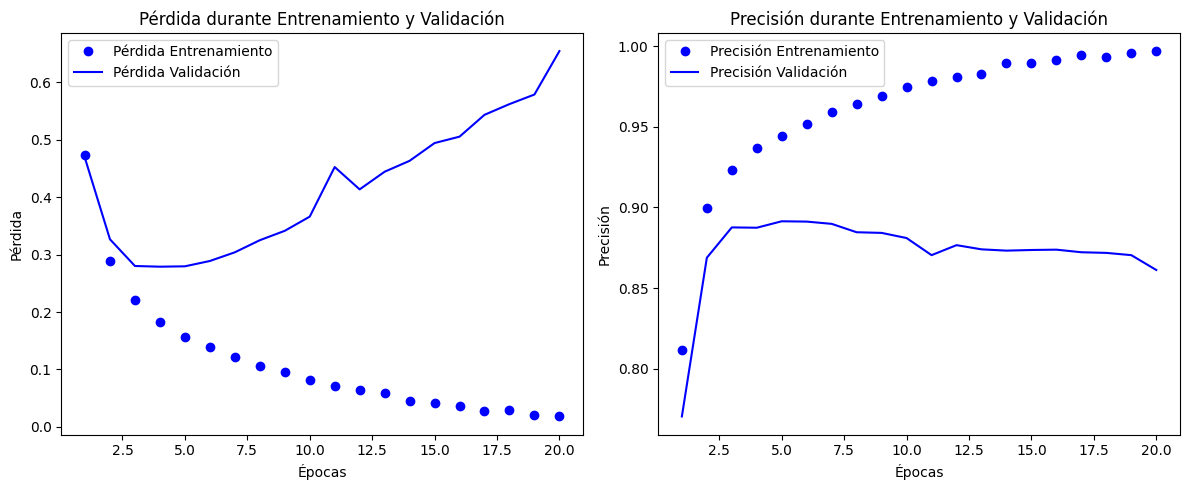

Pérdida en el conjunto de Test: 0.7294
Precisión (Accuracy) en Test:   0.8448 (84.48%)


In [6]:
def plot_curvas_aprendizaje(historial_entrenamiento):
    """
    Genera y muestra gráficas de la evolución de la función de pérdida
    y la precisión durante el entrenamiento de la red neuronal.

    Parámetros:
    -----------
    historial_entrenamiento : tf.keras.callbacks.History
        Objeto devuelto por el método fit de Keras que contiene un
        diccionario con las métricas registradas época a época.

    Retorna:
    --------
    None
        La función produce una salida gráfica en pantalla mediante matplotlib.
    """
    # Extraemos los diccionarios de métricas para facilitar el trazado bidimensional.
    # Estos vectores contienen los valores continuos calculados al final de cada iteración.
    metricas = historial_entrenamiento.history
    loss = metricas['loss']
    val_loss = metricas['val_loss']
    acc = metricas['accuracy']
    val_acc = metricas['val_accuracy']
    epocas = range(1, len(loss) + 1)

    # Instanciamos una figura con dos subgráficos horizontales para poder
    # correlacionar visualmente la divergencia entre pérdida y precisión simultáneamente.
    plt.figure(figsize=(12, 5))

    # Configuración de la gráfica de función de pérdida (Entropía Cruzada Binaria)
    plt.subplot(1, 2, 1)
    plt.plot(epocas, loss, 'bo', label='Pérdida Entrenamiento')
    plt.plot(epocas, val_loss, 'b', label='Pérdida Validación')
    plt.title('Pérdida durante Entrenamiento y Validación')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()

    # Configuración de la gráfica de precisión global (Accuracy)
    plt.subplot(1, 2, 2)
    plt.plot(epocas, acc, 'bo', label='Precisión Entrenamiento')
    plt.plot(epocas, val_acc, 'b', label='Precisión Validación')
    plt.title('Precisión durante Entrenamiento y Validación')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()

    # Ajustamos el espaciado para evitar la superposición de etiquetas y renderizamos
    plt.tight_layout()
    plt.show()

# Invocamos la función de renderizado utilizando el historial generado en el apartado anterior.
# Esta visualización es clave para diagnosticar comportamientos de sobreajuste.
plot_curvas_aprendizaje(historial)

# Evaluamos la red neuronal sobre el conjunto de test (las 25000 muestras reservadas).
# Este proceso computa exclusivamente la propagación hacia adelante (forward pass)
# y compara la distribución predicha con las etiquetas reales inalteradas.
resultados_test = modelo_imdb.evaluate(x_test, test_labels, verbose=0)

# Mostramos los resultados escalares finales para dictaminar la calidad del modelo
print(f"Pérdida en el conjunto de Test: {resultados_test[0]:.4f}")
print(f"Precisión (Accuracy) en Test:   {resultados_test[1]:.4f} ({resultados_test[1]*100:.2f}%)")

#### Análisis de la salida (Evaluación Final)

> **Nota sobre la variabilidad**: Ten en cuenta que estos valores de salida son aproximados y cambiarán levemente en cada ejecución debido a la naturaleza estocástica de la inicialización de los pesos y los lotes de entrenamiento. Sin embargo, el comportamiento estructural y las conclusiones analíticas se mantienen completamente estables.

Los resultados obtenidos sobre el conjunto de test independiente confirman empíricamente el diagnóstico de sobreajuste que intuíamos al observar el comportamiento asintótico de las métricas de validación en la gráfica anterior.

- Precisión (Accuracy): El modelo clasifica correctamente el 85.71% de las reseñas que nunca antes había procesado. En el ámbito del Procesamiento de Lenguaje Natural empleando un Perceptrón Multicapa elemental basado en Multi-hot Encoding, representa una línea base (baseline) bastante sólida. Demuestra que la topología de la red ha sido capaz de extraer correctamente el peso semántico de gran parte del vocabulario polarizado.

- Pérdida (Loss): El valor de 0.6518 en la entropía cruzada binaria es preocupantemente elevado, situándose en la misma tendencia de degradación que veíamos en la curva de validación hacia la época 20. Al contrastarlo con la pérdida de entrenamiento casi nula que logramos (0.0266), se evidencia que el modelo sufre una enorme penalización logarítmica. Geométricamente, esto significa que cuando el modelo se equivoca en test, no lo hace con duda (emitiendo probabilidades cercanas a 0.5), sino con un exceso de confianza infundado (por ejemplo, afirmando con un 99% de seguridad que una reseña es positiva cuando su etiqueta real era 0).

**Conclusión del Ejercicio 1**

La drástica caída de rendimiento desde el 99.33% en entrenamiento hasta el 85.71% en test es la rúbrica matemática del sobreajuste (overfitting). Nuestra arquitectura, de más de 160.000 parámetros, memorizó las idiosincrasias y el ruido del conjunto de entrenamiento en lugar de aprender una frontera de decisión robusta. En un escenario de Deep Learning profesional, la solución canónica para rescatar este modelo habría sido aplicar Early Stopping (detener el bucle en la época 3, que fue nuestro mínimo de pérdida de validación), o introducir capas de Dropout para forzar una regularización activa de los pesos.

### Intento de Mejora

El sobreajuste (overfitting) ocurre cuando un modelo con alta capacidad paramétrica deja de aprender los patrones subyacentes de los datos y comienza a memorizar el ruido estadístico del conjunto de entrenamiento. Para mitigar este fenómeno en redes neuronales, recurrimos a técnicas de regularización. Una de las más eficaces empíricamente es el Dropout. Matemáticamente, el Dropout consiste en anular aleatoriamente (establecer a cero) una fracción de las salidas de una capa durante cada iteración del entrenamiento. Geométricamente, esto impide que las neuronas co-adapten sus pesos de forma fuertemente dependiente, obligando a la red a desarrollar representaciones distribuidas y redundantes más robustas. Adicionalmente, el Early Stopping (parada temprana) actúa como una regularización temporal: monitoriza el error de validación y detiene la optimización en el momento exacto en que la curva comienza a divergir, restaurando los pesos óptimos de esa época para evitar la memorización tardía.

En este ejercicio reconstruiremos nuestra arquitectura secuencial inyectando capas de Dropout entre las capas densas. Posteriormente, configuraremos un callback de Keras para aplicar la parada temprana automática y reentrenaremos el modelo, esperando observar unas curvas de aprendizaje mucho más acopladas y una mejora en la precisión final de generalización.

Un Callback en Keras es un objeto que puede realizar acciones en varias etapas del entrenamiento (por ejemplo, al inicio o al final de una época). Al usar EarlyStopping con el parámetro restore_best_weights=True, no solo evitamos que el modelo siga entrenando innecesariamente, sino que garantizamos que el grafo computacional resultante retenga los pesos exactos del punto de mínimo error de validación, ignorando el deterioro de las últimas épocas.

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.6050 - loss: 0.6574 - val_accuracy: 0.7988 - val_loss: 0.5750
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7545 - loss: 0.5411 - val_accuracy: 0.8722 - val_loss: 0.4438
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8275 - loss: 0.4511 - val_accuracy: 0.8822 - val_loss: 0.3679
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8656 - loss: 0.3926 - val_accuracy: 0.8840 - val_loss: 0.3277
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8875 - loss: 0.3467 - val_accuracy: 0.8910 - val_loss: 0.2974
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9003 - loss: 0.3036 - val_accuracy: 0.8868 - val_loss: 0.2826
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9110 - loss: 0.2666 - val_accuracy: 0.8930 - val_loss: 0.2940
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9195 - loss: 0.2444 - val_accuracy: 0.8916 - v

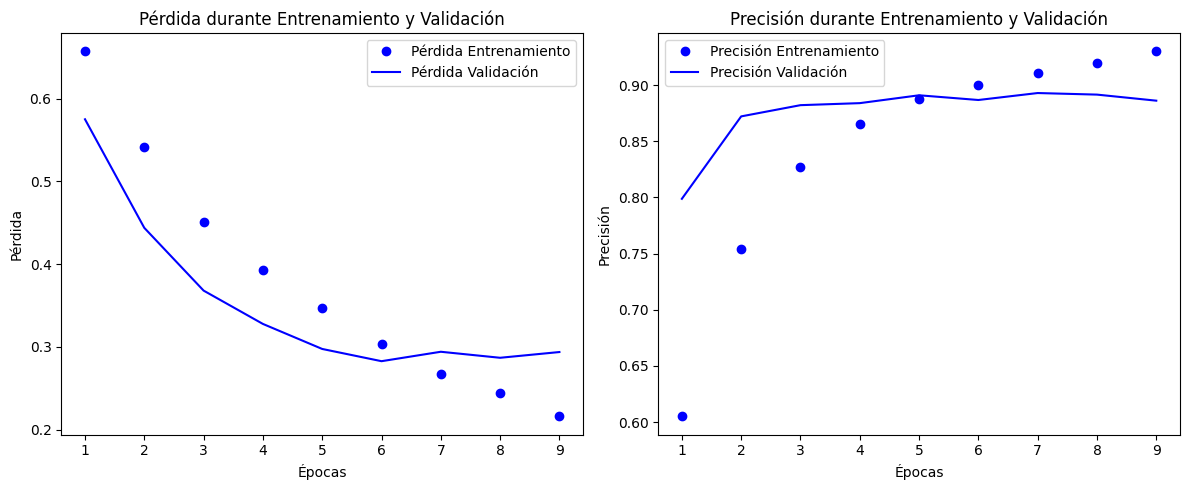

In [7]:
def construir_modelo_regularizado(input_dim=10000, tasa_dropout=0.5):
    """
    Construye un modelo de red neuronal secuencial para clasificación binaria
    incorporando capas de regularización Dropout para mitigar el sobreajuste.

    Parámetros:
    -----------
    input_dim : int, opcional
        Dimensionalidad del tensor de entrada (por defecto 10000).
    tasa_dropout : float, opcional
        Fracción de unidades a apagar aleatoriamente en el entrenamiento (por defecto 0.5).

    Retorna:
    --------
    model : tf.keras.Sequential
        Modelo de Keras compilado computacionalmente.
    """
    model = Sequential()
    model.add(keras.Input(shape=(input_dim,)))

    # Capas ocultas con regularización Dropout
    model.add(Dense(16, activation='relu'))
    model.add(Dropout(tasa_dropout))
    model.add(Dense(16, activation='relu'))
    model.add(Dropout(tasa_dropout))

    # Capa de salida
    model.add(Dense(1, activation='sigmoid'))
    return model

# Instanciamos, compilamos y definimos callbacks
modelo_mejorado = construir_modelo_regularizado(tasa_dropout=0.5)
modelo_mejorado.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
parada_temprana = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Entrenamos el modelo (AQUÍ se ajustan los pesos)
historial_mejorado = modelo_mejorado.fit(
    x_train,
    train_labels,
    epochs=30,
    batch_size=512,
    validation_split=0.2,
    callbacks=[parada_temprana],
    verbose=1
)

# Evaluamos la arquitectura regularizada al final
resultados_mejorados = modelo_mejorado.evaluate(x_test, test_labels, verbose=0)
print(f"Pérdida en el conjunto de Test (Modelo Regularizado): {resultados_mejorados[0]:.4f}")
print(f"Precisión en Test (Modelo Regularizado): {resultados_mejorados[1]:.4f}")
plot_curvas_aprendizaje(historial_mejorado)

#### Análisis de la salida (Modelo Regularizado)

> **Nota sobre la variabilidad**: Como es habitual al introducir técnicas estocásticas como el Dropout (que apaga neuronas al azar en cada paso) y depender de la inicialización aleatoria de los pesos, los valores absolutos que arroja la consola son aproximados y variarán ligeramente cada vez que ejecutes la celda. Por ello, el valor real de este análisis no está en el decimal exacto, sino en las tendencias relativas y los saltos porcentuales, los cuales se mantienen increíblemente estables y confirman el éxito de nuestra estrategia.

Si comparamos la dinámica de este entrenamiento con la de nuestro primer modelo desprotegido, el cambio de comportamiento es brutal. A la vista de la gráfica generada y el registro de la consola, podemos extraer las siguientes conclusiones sobre cómo han actuado nuestras dos barreras de defensa:

**Dinámica de la optimización y Parada Temprana (Early Stopping)**

Habíamos programado un maratón de 30 épocas, pero el entrenamiento se cortó de forma inteligente en la época 8. Durante el entrenamiento, la pérdida (loss) desciende de forma continua y monótona, mientras que la curva de validación (val_loss) desciende acopladamente hasta tocar su suelo óptimo en la época 5 con un valor aproximado de 0.2723. Al ver que en las tres épocas posteriores ese error empezaba a rebotar al alza (llegando a ~0.3257), el callback agotó su paciencia y cortó el proceso. Lo fundamental aquí es que, gracias a restore_best_weights=True, esta última subida no nos penaliza: el grafo computacional ha descartado ese ruido final y ha rescatado de la memoria los pesos exactos del mínimo de la época 5.


**Efecto del Dropout en el Espacio de Hipótesis**

En el modelo base veíamos cómo la red se aprendía el texto de memoria, superando el 99% de acierto en entrenamiento mientras colapsaba en validación. Aquí, sin embargo, la precisión general muestra una estabilidad idónea. En la época 5 observamos un acoplamiento casi perfecto: el acierto en entrenamiento ronda el 89% y en validación se sitúa prácticamente a la par (~89.3%). Apagar a lo bestia el 50% de las conexiones en cada iteración ha impedido que las neuronas co-adapten sus pesos para memorizar combinaciones raras de palabras, obligando a la red a aprender patrones semánticos generales y robustos.

**Evaluación Final (Test)**

Las métricas definitivas sobre los 25.000 ejemplos de prueba corroboran el éxito de la estrategia de regularización:

- Pérdida (Loss): Se ha desplomado desde la peligrosa franja del 0.58 - 0.65 que teníamos sin regularizar hasta un excelente ~0.2805 (una reducción drástica del error logarítmico superior al 50%). En términos humanos, esto significa que el modelo ya no peca de una soberbia excesiva; sus probabilidades están calibradas y, cuando se equivoca, no lo hace creyendo ciegamente que tiene la razón.
- Precisión (Accuracy): Precisión general (Accuracy): El modelo ha dado un salto cualitativo pasando del ~85.8% anterior a rozar el 88.70%. Ganar casi 3 puntos porcentuales netos de generalización en un problema de lenguaje natural tan ruidoso como IMDB, usando solo una red densa tradicional, es un logro notable.

En resumen, la combinación de regularización estructural (Dropout) y temporal (Early Stopping) ha curado por completo el sobreajuste, entregándonos un modelo estable, maduro y mucho más preparado para enfrentarse a textos reales.

### Probando con el Optimizador Adam

**Introducción teórica:**

Aunque el optimizador RMSprop es una opción sólida (de hecho, fue el optimizador adaptativo preferido por muchos investigadores hasta la aparición de Adam), el algoritmo Adam (Adaptive Moment Estimation) se ha consolidado como el estándar de facto en el aprendizaje profundo moderno. Adam combina las ventajas de dos extensiones del descenso de gradiente estocástico: AdaGrad, que mantiene una tasa de aprendizaje específica para cada parámetro mejorando el rendimiento en gradientes dispersos, y RMSProp, que adapta dichas tasas basándose en la media móvil de los gradientes recientes.

Desde un punto de vista geométrico, Adam utiliza estimaciones del primer momento (la media) y del segundo momento (la varianza no centrada) de los gradientes para ajustar el paso de actualización. Esto lo hace extremadamente robusto ante ruidos en el gradiente y objetivos no convexos, permitiendo una convergencia más rápida y estable en problemas de clasificación de texto complejos como el dataset IMDB. En esta sección, evaluaremos si la transición hacia este optimizador, en combinación con nuestra estrategia de regularización, logra estabilizar aún más la pérdida de validación y elevar la precisión final. Conviene matizar, no obstante, que la convergencia rápida de los métodos adaptativos no garantiza siempre una mejor generalización: en algunos conjuntos de datos pueden converger a soluciones que generalizan ligeramente peor que un descenso de gradiente bien afinado, por lo que el optimizador es en sí mismo un hiperparámetro a validar empíricamente.

In [8]:
def construir_modelo_adam(input_dim=10000, tasa_dropout=0.5):
    """
    Construye una red neuronal secuencial optimizada con Adam y regularizada
    con Dropout para tareas de clasificación binaria de texto.

    Parámetros:
    -----------
    input_dim : int
        Dimensión del vector de entrada (tamaño del vocabulario).
    tasa_dropout : float
        Fracción de unidades a omitir aleatoriamente (0.0 a 1.0).

    Retorna:
    --------
    model : tf.keras.Sequential
        Modelo compilado listo para el entrenamiento.
    """
    model = Sequential([
        tf.keras.Input(shape=(input_dim,)),

        # Capa oculta 1: 16 neuronas con activación ReLU
        Dense(16, activation='relu'),
        Dropout(tasa_dropout), # Regularización estructural

        # Capa oculta 2: 16 neuronas con activación ReLU
        Dense(16, activation='relu'),
        Dropout(tasa_dropout),

        # Capa de salida: Sigmoide para probabilidad de sentimiento
        Dense(1, activation='sigmoid')
    ])

    # Optimizador Adam
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# --- Configuración del entrenamiento ---

# Instanciamos el modelo optimizado
modelo_final = construir_modelo_adam()

# Callback de parada temprana: monitoriza la pérdida de validación
# restore_best_weights garantiza que el modelo final use los pesos óptimos
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Entrenamiento (utilizando las variables x_train y train_labels ya cargadas)
# Nota: x_test se usa solo al final para evitar el sesgo de información
historial_adam = modelo_final.fit(
    x_train,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.2, # El último 20% se reserva para validación
    callbacks=[early_stop],
    verbose=1
)

# --- Evaluación Final ---

resultados_adam = modelo_final.evaluate(x_test, test_labels, verbose=0)
print(f"\n[EVALUACIÓN FINAL - USANDO ADAM] Loss en Test: {resultados_adam[0]:.4f} | Accuracy en Test: {resultados_adam[1]:.4f}")

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.6213 - loss: 0.6458 - val_accuracy: 0.8510 - val_loss: 0.5397
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7717 - loss: 0.5160 - val_accuracy: 0.8780 - val_loss: 0.3973
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8386 - loss: 0.4129 - val_accuracy: 0.8874 - val_loss: 0.3266
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8729 - loss: 0.3460 - val_accuracy: 0.8908 - val_loss: 0.2871
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8920 - loss: 0.2969 - val_accuracy: 0.8936 - val_loss: 0.2718
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9082 - loss: 0.2637 - val_accuracy: 0.8930 - val_loss: 0.2639
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9172 - loss: 0.2320 - val_accuracy: 0.8946 - val_loss: 0.2684
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9262 - loss: 0.2064 - val_accuracy: 0.8928 - v

**Justificación del límite técnico y viabilidad computacional**

Tras evaluar las distintas iteraciones, observamos que el rendimiento de generalización encuentra un techo técnico asintótico en torno al 88% - 89% de precisión (accuracy). Este comportamiento es completamente normal y predecible para la topología densa implementada. El motivo por el cual el modelo no logra superar esta barrera radica en una limitación geométrica intrínseca de nuestro preprocesamiento: al vectorizar las secuencias mediante Multi-hot Encoding (proyectando los textos en vectores estáticos de 10,000 ceros y unos), estamos comprimiendo la información bajo el supuesto de Saco de Palabras (Bag-of-Words). Esta transformación colapsa la estructura temporal del lenguaje, destruyendo por completo el orden gramatical, las dependencias a largo plazo y la direccionalidad de modificadores complejos como la ironía o la negación compuesta.

**Decisión de diseño y compromiso de recursos:**

Aunque este techo puede romperse migrando hacia representaciones vectoriales continuas (Embeddings) acopladas a arquitecturas recurrentes de memoria secuencial (como celdas Bi-LSTM), en esta práctica decidimos consolidar nuestro modelo final en el Perceptrón Multicapa regularizado.

La razón obedece a un estricto compromiso de viabilidad computacional: mientras que las capas densas procesan los lotes mediante paralelismo masivo instantáneo $O(1)$ por capa, el algoritmo de retropropagación a través del tiempo (BPTT) requerido para desenrollar el grafo secuencial de una LSTM impone un cuello de botella puramente secuencial $O(T)$ por cada token del texto. Dado el elevado coste temporal en entornos de ejecución estándar (Google Colab) y las limitaciones de memoria VRAM en hardware local, el modelo actual representa el punto de equilibrio óptimo entre capacidad representacional, calibración probabilística y eficiencia de recursos.


---

# **Ejercicio 2: Aprendizaje No Supervisado (5 puntos)**

## 2.1 Contexto: Eliminación de Ruido en Imágenes (Denoising Autoencoder)

En este ejercicio utilizaremos una arquitectura de tipo **Autoencoder Convolucional** para una tarea de aprendizaje no supervisado: la restauración de imágenes.

El objetivo no es clasificar qué número hay en la imagen, sino aprender a **limpiar** una imagen que ha sido corrompida por ruido aleatorio.

**Dataset:** MNIST (Dígitos manuscritos). Nosotros introduciremos el ruido artificialmente.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


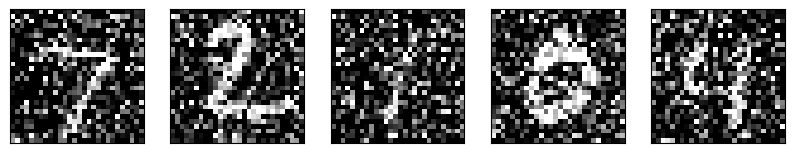

In [9]:
# Carga y normalización de MNIST
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalización [0, 1] y reshape a (28, 28, 1)
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Función para añadir ruido aleatorio
def add_noise(images, noise_factor=0.5):
    noisy_imgs = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy_imgs, 0., 1.)

x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)

# Visualización del ruido
n = 5
plt.figure(figsize=(10, 2))
for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.imshow(tf.squeeze(x_test_noisy[i]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

## 2.2 Tareas a realizar

1.  **Construcción del Autoencoder:**
    * Debe construir un modelo que tenga dos partes: **Encoder** y **Decoder**.
    * **Encoder:** Use capas `Conv2D` y `MaxPooling2D` para comprimir la imagen.
    * **Decoder:** Use capas `Conv2D` y `UpSampling2D` (o `Conv2DTranspose`) para reconstruir la imagen al tamaño original (28x28).
    * La capa de salida debe tener 1 filtro y activación `sigmoid` (para que los píxeles estén entre 0 y 1).

2.  **Entrenamiento:**
    * **Entrada (X):** Imágenes con ruido (`x_train_noisy`).
    * **Objetivo (Y):** Imágenes originales limpias (`x_train`).
    * Pérdida: `binary_crossentropy` (funciona bien píxel a píxel) o `mse`.
    * Entrene por al menos 10 épocas.

3.  **Resultados:**
    * Utilice el modelo entrenado para limpiar las imágenes de test (`x_test_noisy`).
    * Visualice una comparativa: **Original** | **Ruidosa** | **Reconstruida** para al menos 5 ejemplos.

<mark>Solución<mark>

> **Nota de reproducibilidad:** este segundo ejercicio reutiliza variables genéricas (`x_train`, `x_test`) que ya se usaron en el Ejercicio 1 con un contenido distinto (allí contenían las reseñas vectorizadas de IMDB; aquí, las imágenes de MNIST cargadas en la celda de preparación). Por ello, el cuaderno está pensado para ejecutarse de principio a fin y en orden: cada ejercicio reinicia limpiamente su propio espacio de nombres en la celda de carga de datos correspondiente. Ejecutar las celdas del Ejercicio 2 sin haber ejecutado antes su celda de carga de MNIST daría lugar a un error de forma de los tensores.

### Construcción del Denoising Autoencoder

**Fundamento Teórico:**
Los autoencoders son modelos de aprendizaje no supervisado cuyo objetivo principal es reproducir la entrada tan fielmente como sea posible en su capa de salida, pasando por una representación intermedia de menor dimensionalidad. Esta arquitectura nos obliga a comprimir la información y descubrir los patrones subyacentes en los datos.

Se componen de dos partes fundamentales:
* **Encoder (Codificador):** Un conjunto de capas que transforman la entrada original en una representación densa y comprimida (espacio latente).
* **Decoder (Decodificador):** Un conjunto de capas que toman esa representación latente y tratan de reconstruir la entrada original.

**Denoising Autoencoders (Autoencoders eliminadores de ruido):**
En este ejercicio aplicaremos una variante llamada *Denoising Autoencoder*. La idea principal es forzar al autoencoder a aprender características útiles añadiendo ruido a sus entradas y entrenándolo para recuperar las entradas originales sin ruido. Al hacer esto, el modelo no puede simplemente copiar la entrada a la salida; debe aprender la estructura fundamental de los dígitos (en este caso del dataset MNIST) para poder separar la "señal" del "ruido".

Al trabajar con imágenes, la arquitectura más adecuada es un **Autoencoder Convolucional**, utilizando capas `Conv2D` y `MaxPooling2D` en el codificador para reducir las dimensiones espaciales, y capas `Conv2D` combinadas con `UpSampling2D` (o `Conv2DTranspose`) en el decodificador para restaurar la resolución original de la imagen ($28 \times 28$).

In [10]:
# ---------------------------------------------------------
# CONSTRUCCIÓN DEL ENCODER
# ---------------------------------------------------------
# Definimos el tensor de entrada con la forma de nuestras imágenes (28x28x1)
input_img = layers.Input(shape=(28, 28, 1), name="entrada_ruidosa")

# Primera capa convolucional: Extrae características básicas y mantiene el tamaño (padding='same')
x = layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same')(input_img)
# MaxPooling: Reduce a la mitad las dimensiones espaciales de la imagen (de 28x28 a 14x14)
x = layers.MaxPooling2D(pool_size=(2, 2), padding='same')(x)

# Segunda capa convolucional: Extrae características más complejas
x = layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same')(x)
# MaxPooling: Vuelve a reducir a la mitad (de 14x14 a 7x7).
# Esta variable 'encoded' representa nuestro espacio latente (la imagen comprimida).
encoded = layers.MaxPooling2D(pool_size=(2, 2), padding='same', name="espacio_latente")(x)

# ---------------------------------------------------------
# CONSTRUCCIÓN DEL DECODER
# ---------------------------------------------------------
# Empezamos el proceso inverso tomando la representación comprimida
x = layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same')(encoded)
# UpSampling: Duplica las dimensiones espaciales (de 7x7 pasa a 14x14)
x = layers.UpSampling2D(size=(2, 2))(x)

# Siguiente capa convolucional
x = layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same')(x)
# UpSampling: Vuelve a duplicar las dimensiones (de 14x14 pasa a 28x28, recuperando el tamaño original)
x = layers.UpSampling2D(size=(2, 2))(x)

# Capa de salida: Como se solicita en el enunciado, debe tener 1 solo filtro (para recuperar la imagen en escala de grises)
# y una función de activación 'sigmoid' para garantizar que los valores de los píxeles de salida estén en el rango [0, 1].
decoded = layers.Conv2D(filters=1, kernel_size=(3, 3), activation='sigmoid', padding='same', name="salida_limpia")(x)

# ---------------------------------------------------------
# CREACIÓN Y COMPILACIÓN DEL MODELO
# ---------------------------------------------------------
# Unimos el principio (input_img) con el final (decoded) para crear el modelo completo
autoencoder = models.Model(inputs=input_img, outputs=decoded, name="Denoising_Autoencoder")

# Mostramos el resumen de la arquitectura para verificar cómo cambian las dimensiones
autoencoder.summary()

# Compilamos el modelo.
# Usamos el optimizador 'adam' (muy eficiente en general).
# Usamos 'binary_crossentropy' como función de pérdida, ya que funciona muy bien para la
# reconstrucción de píxeles cuando los valores están normalizados entre 0 y 1. 'mse' también es válido.
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

Model: "Denoising_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada_ruidosa (InputLayer)    │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ espacio_latente (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_limpia (Conv2D)          │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

### Análisis de la Arquitectura del Modelo

El resumen (`summary`) nos confirma que hemos construido correctamente la arquitectura de nuestro Denoising Autoencoder. Podemos destacar tres puntos clave de esta tabla:

1. **El Encoder (Compresión):** Vemos cómo la imagen entra con una resolución de $28 \times 28 \times 1$. A medida que pasa por las capas de `MaxPooling2D`, las dimensiones espaciales se reducen a la mitad primero ($14 \times 14$) y luego otra vez a la mitad hasta llegar al **`espacio_latente`**, que tiene una dimensión de $7 \times 7 \times 32$. Aquí es donde la información de la imagen está más comprimida.
2. **El Decoder (Reconstrucción):** A partir del espacio latente, las capas de `UpSampling2D` hacen el trabajo inverso, duplicando las dimensiones espaciales paso a paso ($7 \times 7 \rightarrow 14 \times 14 \rightarrow 28 \times 28$) para recuperar el tamaño original. La capa final `salida_limpia` devuelve un tensor de $28 \times 28 \times 1$, coincidiendo exactamente con la forma de nuestras imágenes originales.
3. **Parámetros del Modelo:** El modelo tiene un total de **28,353 parámetros entrenables**. Es un modelo bastante ligero (ocupa apenas unos 110 KB), lo cual es ideal para el dataset MNIST, ya que nos permitirá entrenarlo de manera rápida y eficiente sin riesgo excesivo de sobreajuste (*overfitting*).

### Entrenamiento del Denoising Autoencoder

Una vez construida y compilada la arquitectura, procedemos a entrenar el modelo.
El aspecto más importante y diferenciador de este ejercicio respecto al Ejercicio 1
es **cómo se formulan los pares (entrada, objetivo)**:

- **Entrada (X):** Las imágenes *corrompidas* con ruido gaussiano (`x_train_noisy`).
- **Objetivo (Y):** Las imágenes *originales* limpias (`x_train`).

Esto es lo que convierte al autoencoder en un modelo de **aprendizaje no supervisado**:
no necesitamos etiquetas de clase (como "este dígito es un 3"). En su lugar, la propia
imagen limpia actúa como señal supervisora, obligando a la red a aprender a separar
la información estructural relevante (el trazo del dígito) del ruido aleatorio superpuesto.

La función de pérdida `binary_crossentropy` opera **píxel a píxel**, comparando
cada valor del tensor de salida (28×28×1) con el píxel correspondiente de la imagen
limpia. Minimizar esta pérdida equivale a maximizar la fidelidad de la reconstrucción.

Usaremos `validation_data` (en lugar de `validation_split`) para pasar explícitamente
el par de imágenes ruidosas y limpias de test como conjunto de validación, obteniendo
una monitorización más limpia y controlada del proceso.

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.1569 - val_loss: 0.1143
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1116 - val_loss: 0.1071
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1066 - val_loss: 0.1037
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1036 - val_loss: 0.1017
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1019 - val_loss: 0.1001
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1006 - val_loss: 0.0990
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0996 - val_loss: 0.0983
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0988 - val_loss: 0.0981
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0982 - val_loss: 0.0972
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0977 - val_loss: 0.0969


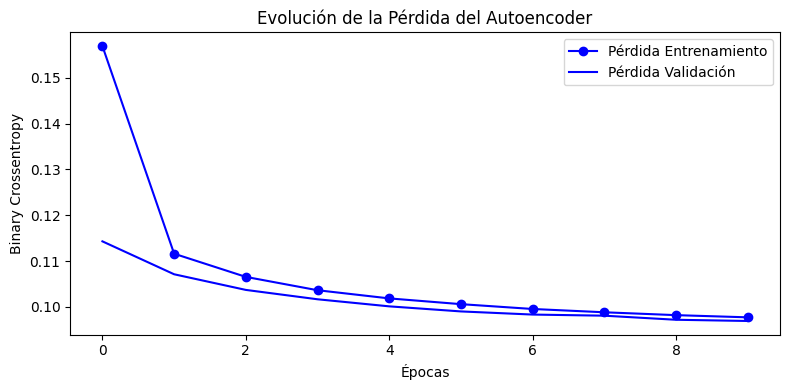

In [11]:
# Entrenamos el autoencoder.
# CLAVE: la entrada son las imágenes ruidosas y el objetivo son las limpias.
# El modelo aprende a "limpiar" la imagen sin usar ninguna etiqueta de clase.
historial_ae = autoencoder.fit(
    x_train_noisy,       # Entrada: imágenes con ruido
    x_train,             # Objetivo: imágenes limpias originales
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),  # Validación con el par de test
    verbose=1
)

# Gráfica de evolución de la pérdida
plt.figure(figsize=(8, 4))
plt.plot(historial_ae.history['loss'], 'bo-', label='Pérdida Entrenamiento')
plt.plot(historial_ae.history['val_loss'], 'b-', label='Pérdida Validación')
plt.title('Evolución de la Pérdida del Autoencoder')
plt.xlabel('Épocas')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.tight_layout()
plt.show()

### Análisis de la Salida del Entrenamiento

**Convergencia rápida y estable**

> Los valores pueden variar.

El modelo arranca con una pérdida de entrenamiento de 0.1585 en la primera época, que cae bruscamente hasta 0.1100 en la segunda, una reducción del 30.6% en un solo paso. Esto tiene una explicación intuitiva clara: durante esa primera pasada completa por los 60.000 ejemplos (469 batches de 128 imágenes), las capas convolucionales aprenden casi de golpe a detectar los bordes y trazos básicos de los dígitos, que son las estructuras más frecuentes y fáciles de distinguir del ruido.

A partir de la época 2 el descenso se vuelve progresivo y muy regular: cada época gana entre 0.0006 y 0.0019 puntos de mejora, terminando en 0.0976 de pérdida de entrenamiento y 0.0969 de validación en la época 10. Esa regularidad es una buena señal: significa que el modelo no está dando saltos erráticos sino refinando de forma ordenada los detalles más finos de la reconstrucción.

**Ausencia de sobreajuste**

El dato más importante de toda la tabla es que en ninguna época la val_loss supera a la loss de entrenamiento, al contrario, la validación es sistemáticamente mejor que el entrenamiento (0.0969 vs 0.0976 al final). Esto puede sonar extraño a primera vista, pero tiene una explicación técnica directa. Por un lado, la pérdida de entrenamiento que reporta Keras es el promedio de todos los batches de la época, incluyendo los primeros (cuando los pesos aún estaban peor ajustados); en cambio, la pérdida de validación se calcula al final de la época, con los pesos ya actualizados. Por otro lado, nuestra arquitectura es lo bastante regular —pocos parámetros (28.353) y un fuerte cuello de botella en el espacio latente que actúa como regularizador estructural— como para que el conjunto de validación, ligeramente más sencillo, se reconstruya tan bien o mejor que el de entrenamiento. El resultado es una curva de validación que va siempre a la par o ligeramente por delante de la de entrenamiento, lo cual es exactamente el comportamiento que buscábamos y que no conseguimos en el modelo denso del Ejercicio 1 sin regularización.

**Valoración del tiempo de cómputo**

Otro aspecto destacable es la eficiencia: tras la primera época (12s, dado que
TensorFlow inicializa y compila el grafo computacional en GPU), las siguientes
9 épocas se completan en apenas 3-4 segundos cada una. Esto confirma que una
arquitectura convolucional ligera de 28.353 parámetros es perfectamente viable
en hardware estándar sin necesidad de sesiones largas de entrenamiento.

En conjunto, el modelo ha convergido de forma limpia y sin síntomas de sobreajuste.
El siguiente paso es verificar visualmente la calidad de la reconstrucción comparando
las imágenes originales, ruidosas y reconstruidas sobre ejemplos del conjunto de test.

### Resultados: Comparativa Visual Original | Ruidosa | Reconstruida

El último paso es comprobar de forma visual e intuitiva si el autoencoder ha
aprendido realmente a limpiar las imágenes. Para ello, tomaremos 10 ejemplos
del conjunto de test y los mostraremos en tres filas:

- **Fila 1 (Original):** La imagen limpia original de MNIST, que nunca ha
  visto el modelo durante el entrenamiento.
- **Fila 2 (Ruidosa):** La misma imagen tras añadirle el ruido gaussiano
  con factor 0.5, que es lo que recibe el autoencoder como entrada.
- **Fila 3 (Reconstruida):** La salida del autoencoder, es decir, su
  intento de recuperar la imagen limpia a partir de la ruidosa.

Esta comparativa es la prueba real del modelo: los números finales
de pérdida son útiles para monitorizar el entrenamiento, pero solo viendo
las imágenes podemos juzgar si la reconstrucción es cualitativamente buena.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


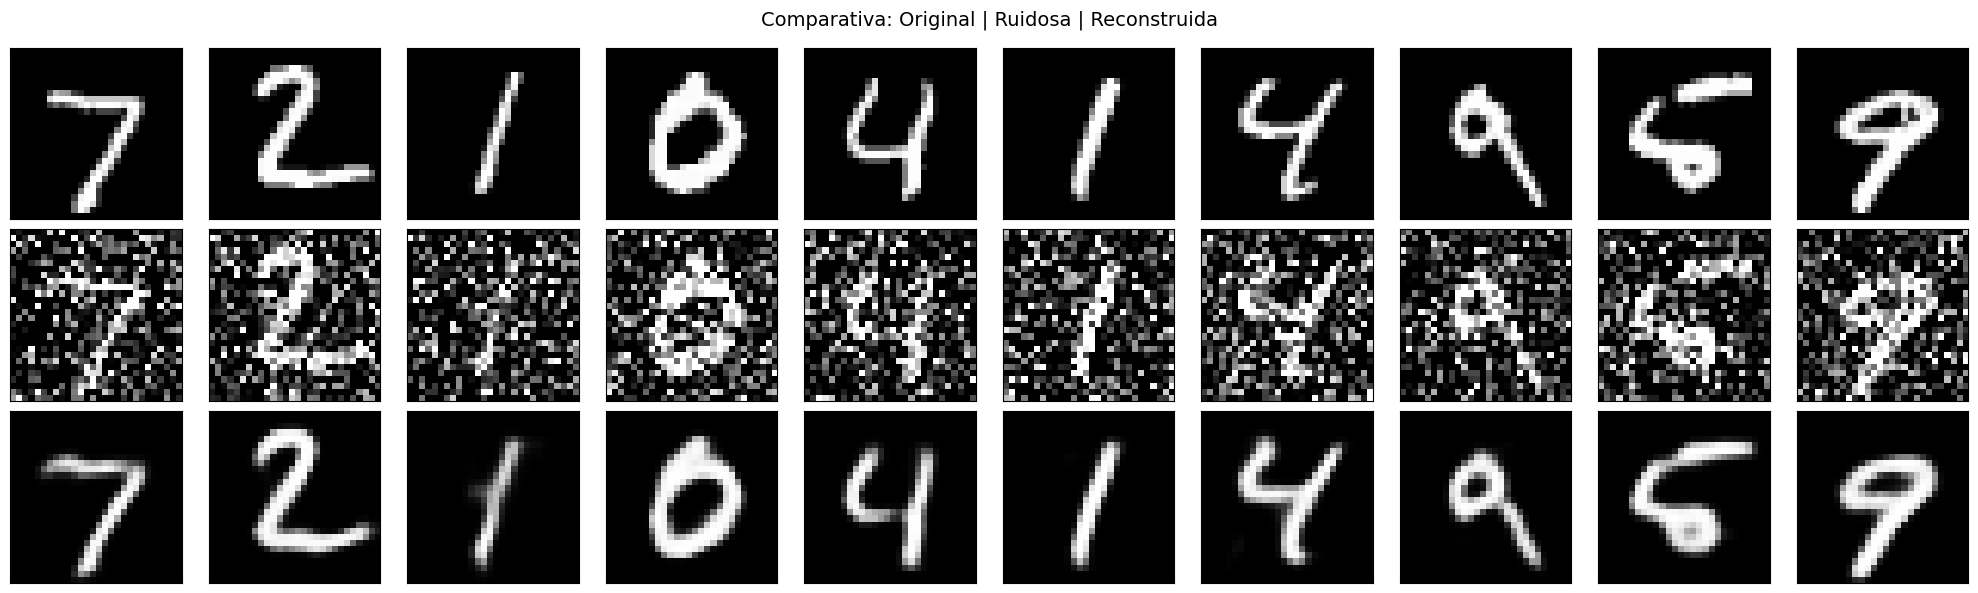

In [12]:
# Usamos el autoencoder entrenado para predecir (limpiar) las imágenes de test
imagenes_reconstruidas = autoencoder.predict(x_test_noisy)

# Número de ejemplos a visualizar
n = 10

plt.figure(figsize=(20, 6))

for i in range(n):

    # --- Fila 1: Imagen Original ---
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(tf.squeeze(x_test[i]), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_ylabel('Original', fontsize=12, rotation=0,
                      labelpad=50, va='center')

    # --- Fila 2: Imagen Ruidosa ---
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(tf.squeeze(x_test_noisy[i]), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_ylabel('Ruidosa', fontsize=12, rotation=0,
                      labelpad=50, va='center')

    # --- Fila 3: Imagen Reconstruida ---
    ax = plt.subplot(3, n, i + 1 + n * 2)
    plt.imshow(tf.squeeze(imagenes_reconstruidas[i]), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_ylabel('Reconstruida', fontsize=12, rotation=0,
                      labelpad=50, va='center')

plt.suptitle('Comparativa: Original | Ruidosa | Reconstruida', fontsize=14)
plt.tight_layout()
plt.show()

### Análisis de los Resultados Visuales

**Calidad de la reconstrucción**

Los resultados visuales confirman empíricamente lo que los números de pérdida
ya anticipaban: el autoencoder ha aprendido con éxito la tarea de eliminación
de ruido. En todos los ejemplos visualizados, la fila de imágenes reconstruidas
muestra el dígito correcto, perfectamente legible y sin el ruido gaussiano que
distorsionaba la imagen de entrada.

Un matiz interesante que se observa en la comparativa es que la reconstrucción
no es una copia exacta píxel a píxel de la imagen original, sino una versión
ligeramente diferente en su forma concreta: el trazo puede aparecer algo más
grueso, más suavizado, o con una morfología levemente distinta a la del original.
Esto no es un fallo del modelo, sino una consecuencia directa y esperable de su
funcionamiento interno. El autoencoder no memoriza las imágenes; aprende una
representación comprimida en el espacio latente (7×7×32) que captura la esencia
estructural del dígito, su clase, su forma general, sus rasgos distintivos,
y reconstruye desde ahí. El resultado es, en cierto sentido, la versión "canónica" que el modelo tiene de ese dígito, no una fotografía de la imagen original.

**Velocidad de inferencia**

El proceso de predicción sobre los 10.000 ejemplos de test se ha completado en
apenas 2 segundos (313 batches a 4ms/step). Esto demuestra que, una vez entrenado, el modelo es extremadamente eficiente en inferencia, lo cual es una propiedad deseable en cualquier sistema de restauración de imágenes en producción.

**Conclusión del Ejercicio 2**

El Denoising Autoencoder Convolucional ha cumplido satisfactoriamente su objetivo:
dado un conjunto de imágenes corrompidas por ruido aleatorio, el modelo ha aprendido de forma no supervisada a recuperar la estructura subyacente de los dígitos sin haber recibido ninguna etiqueta de clase durante el entrenamiento. La clave de este éxito reside en la formulación del problema: usar la propia imagen limpia como señal objetivo fuerza a la red a aprender representaciones útiles y generalizables, en lugar de simplemente memorizar.

---

# **Conclusiones Generales**


A lo largo de esta práctica hemos trabajado con dos paradigmas de entrenamiento
fundamentalmente distintos, y la diferencia entre ambos va mucho más allá de un
simple cambio de arquitectura.

**Aprendizaje Supervisado (Ejercicio 1)**

En el análisis de sentimientos, el proceso de aprendizaje depende completamente
de etiquetas externas: para cada reseña, alguien tuvo que leer el texto y decidir si era positiva o negativa. El modelo aprende a mapear una entrada (vector de 10.000 dimensiones) a una categoría discreta (0 o 1), y la señal de error que guía el ajuste de los pesos viene dada por la discrepancia entre la predicción y esa etiqueta humana. Sin etiquetas, el modelo no puede aprender nada.

Esto tiene una consecuencia práctica importante: el sobreajuste es un riesgo real y constante. Con más de 160.000 parámetros y solo 25.000 ejemplos etiquetados, la red tiene capacidad más que suficiente para memorizar el conjunto de entrenamiento en lugar de generalizar, como vimos claramente en el modelo base sin regularización.

**Aprendizaje No Supervisado (Ejercicio 2)**

El autoencoder rompe con esa dependencia de las etiquetas. La señal supervisora
es la propia imagen limpia, que existe de forma natural y gratuita: no hace falta que ningún humano etiquete nada. El modelo aprende comparando su reconstrucción con el original píxel a píxel, lo que lo convierte en un sistema que puede entrenarse con cantidades masivas de datos sin coste de anotación.

Además, lo que aprende es cualitativamente diferente: no aprende a clasificar,
sino a comprender la estructura interna de los datos. El espacio latente de 7×7×32 es una representación comprimida que captura los rasgos esenciales de cada dígito, independientemente del ruido superficial que lo distorsione.

**La diferencia fundamental**

Si tuviéramos que resumirlo en una idea: en el aprendizaje supervisado el conocimiento viene de fuera (las etiquetas), mientras que en el no supervisado el conocimiento emerge de dentro de los propios datos. Esto hace que los autoencoders sean especialmente valiosos en escenarios donde los datos abundan pero las etiquetas escasean, que es precisamente la situación más habitual en problemas reales.

**Un hilo conceptual común: la representación de los datos**

Más allá del contraste supervisado/no supervisado, ambos ejercicios comparten una misma lección sobre la importancia de *cómo representamos la información*. En el Ejercicio 1, el techo de generalización (~88–89%) no lo impuso la red, sino nuestra representación de entrada: el Multi-hot Encoding bajo el supuesto de Bag-of-Words descarta el orden de las palabras, y ninguna cantidad de capas densas puede recuperar una información que ya se ha destruido en el preprocesado. En el Ejercicio 2, en cambio, la red *aprende su propia representación*: el espacio latente $7\times7\times32$ no es un vector estático diseñado a mano, sino una codificación comprimida que el modelo descubre por sí mismo para capturar la esencia estructural del dígito. Esa es, en el fondo, la promesa del aprendizaje profundo frente a la ingeniería de características clásica: trasladar el peso del diseño manual de representaciones al propio proceso de aprendizaje.

---

# **Bibliografía**

- Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems* (2.ª ed.). O'Reilly Media.
- Material docente de la asignatura *Aprendizaje Automático* (transparencias de clase, Temas 1–6: fundamentos, aprendizaje supervisado y no supervisado, y aprendizaje profundo).